# Practical Session : Image segmentation

The objective of this practical session is to perform the segmentation of noisy images of disks using the Context Aggregation Network introduced by Yu and Koltun in 2015.

Yu, F., & Koltun, V. (2015). Multi-scale context aggregation by dilated convolutions. arXiv preprint arXiv:1511.07122.


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from icecream import ic
import keras

## 1. Data generation

The code below allows to simulate images of disks with distinct gray levels. The images are $64 \times 64$ pixels images encoded on 8 bites. An average of $\theta = 5$ disks are randomly generated in each image. The radii of the disks are sampled from independent normal distributions with mean $4$ pixels and standard deviation $0.5$ pixel. The gray level of each disk is drawn randomly from an uniform distribution between $15$ and $200$.
White noise with standard deviation $\sigma = 30$ pixels is then added to the images.

In [60]:
class Data_Generator:
    """
    Class used to generate synthetic images

    Attributes
    ----------

    """
    nx: int
    ny: int # nx*ny shape of the synthetic image
    theta: float # average number of disks per image
    rmean: float # average radius of the disks
    rstd: float # standard deviation of the radii
    vmin: int
    vmax: int # vmin & vmax minimal/maximal gray level of the disks
    sigma: float # standard deviation of the noise
    img: np.ndarray # synthetic image
    img_truth: np.ndarray # ground truth image
    ndisks: int # number of disks


    def __init__(self, size: int, theta: float, rmean: float, rstd: float, vmin: int, vmax: int, sigma: float):
        """
        Constructor

        """

        self.nx, self.ny = size
        self.theta = theta
        self.rmean, self.rstd = rmean, rstd
        self.vmin, self.vmax = vmin, vmax
        self.sigma = sigma

        self.img = np.zeros((self.nx, self.ny))
        self.img_truth = np.zeros((self.nx, self.ny))

    def generate(self):
        """
        Generate a synthetic image
        """

        x = np.linspace(0, self.nx - 1, self.nx)
        y = np.linspace(0, self.ny - 1, self.ny)
        xx, yy = np.meshgrid(x, y)

        self.ndisks = np.random.poisson(self.theta)

        for n in range(self.ndisks):

            xc = np.random.uniform(0, self.nx)
            yc = np.random.uniform(0, self.ny)
            r = np.random.normal(loc=self.rmean, scale=self.rstd)
            v = np.random.uniform(self.vmin, self.vmax)

            mask = np.power(xx - xc, 2) + np.power(yy - yc, 2) - r**2 < 0
            self.img[mask] = v
            self.img_truth[mask] = 1

        noise = self.sigma * np.random.randn(self.nx, self.ny)
        self.img = np.clip(self.img + noise, 0, 255)
        return self.img, self.img_truth

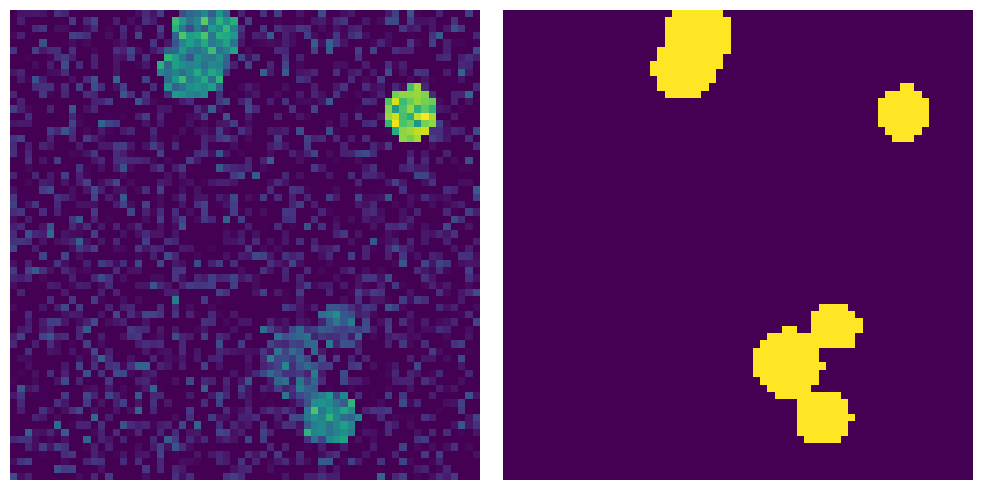

In [82]:
img_rows, img_cols, img_channels = 64, 64, 1
size = (img_rows, img_cols)
theta = 5
rmean = 4
rstd = 0.5
vmin = 15
vmax = 200
sigma = 30

# Image generation
synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)
img, img_truth = synthetic_img.generate()

# Display the generated images
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(img)
ax[1].imshow(img_truth)
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()

*Question 1*. Use the code of the previous cell to generate a dataset of 2000 training image and 200 validation images. The dataset must be at a format compatible with keras (ex: numpy array)

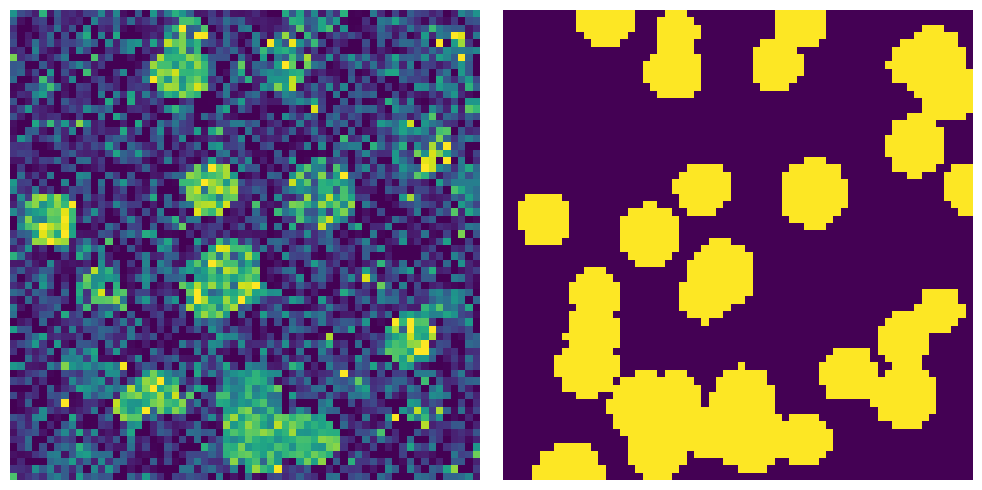

In [64]:
nb_training_samples = 2000
training_img, training_img_true = np.zeros((nb_training_samples, 64, 64)), np.zeros((nb_training_samples, 64, 64))
synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)

for i in range(nb_training_samples):
    image, image_true = synthetic_img.generate()
    training_img[i] = image
    training_img_true[i] = image_true

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_img[5])
ax[1].imshow(training_img_true[5])
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()

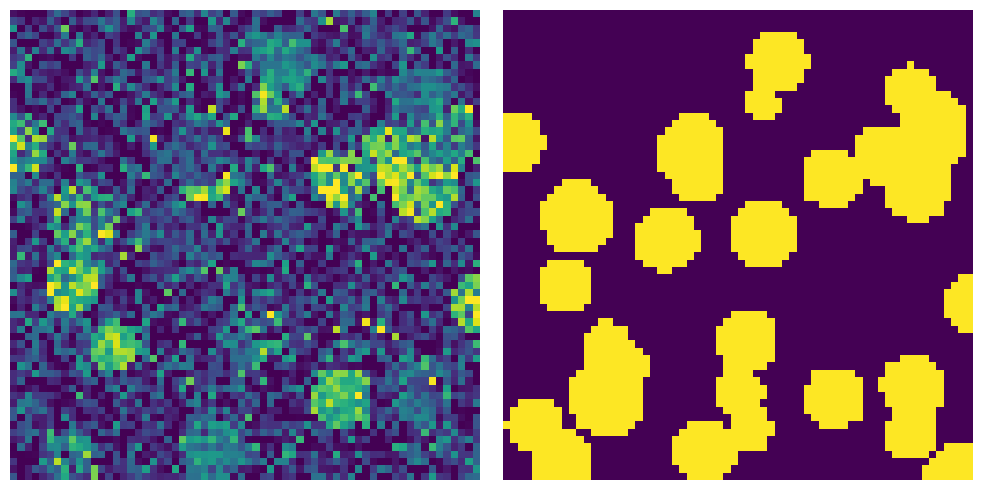

In [92]:
nb_training_samples = 200
validation_img, validation_img_true = np.zeros((nb_training_samples, 64, 64)), np.zeros((nb_training_samples, 64, 64))
synthetic_img = Data_Generator(size, theta, rmean, rstd, vmin, vmax, sigma)

for i in range(nb_training_samples):
    image, image_true = synthetic_img.generate()
    validation_img[i] = image
    validation_img_true[i] = image_true

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(validation_img[5])
ax[1].imshow(validation_img_true[5])
for a in ax.ravel():
    a.set_axis_off()
plt.tight_layout()
plt.show()